In [1]:
import random
from play_8x8_world_game.environment import GridWorld8x8

""" Checking MDP process """
env = GridWorld8x8()

state = random.choice(env.states)
total_rewards = 0
t = 0
while True:
    action = random.choice(env.actions)
    next_state, reward, terminated = env.step(state, action)
    print(
        f"S_{t}({state}), A_{t}({action.name}) -> R_{t+1}({reward}), S_{t+1}({next_state}), {terminated}"
    )
    state = next_state
    total_rewards += reward
    t += 1
    if terminated:
        break

total_rewards
# 

S_0(49), A_0(DOWN) -> R_1(-1.0), S_1(57), False
S_1(57), A_1(RIGHT) -> R_2(-1.0), S_2(58), False
S_2(58), A_2(RIGHT) -> R_3(-1.0), S_3(59), False
S_3(59), A_3(DOWN) -> R_4(-1.0), S_4(59), False
S_4(59), A_4(RIGHT) -> R_5(-1.0), S_5(60), False
S_5(60), A_5(UP) -> R_6(-1.0), S_6(52), False
S_6(52), A_6(DOWN) -> R_7(-1.0), S_7(60), False
S_7(60), A_7(DOWN) -> R_8(-1.0), S_8(60), False
S_8(60), A_8(LEFT) -> R_9(-1.0), S_9(59), False
S_9(59), A_9(LEFT) -> R_10(-1.0), S_10(58), False
S_10(58), A_10(DOWN) -> R_11(-1.0), S_11(58), False
S_11(58), A_11(RIGHT) -> R_12(-1.0), S_12(59), False
S_12(59), A_12(UP) -> R_13(-1.0), S_13(51), False
S_13(51), A_13(LEFT) -> R_14(-1.0), S_14(50), False
S_14(50), A_14(DOWN) -> R_15(-1.0), S_15(58), False
S_15(58), A_15(UP) -> R_16(-1.0), S_16(50), False
S_16(50), A_16(UP) -> R_17(-1.0), S_17(42), False
S_17(42), A_17(UP) -> R_18(-1.0), S_18(34), False
S_18(34), A_18(RIGHT) -> R_19(-1.0), S_19(35), False
S_19(35), A_19(UP) -> R_20(-1.0), S_20(27), False
S_20(

-70.0

In [2]:
# evaluate_policy
from play_8x8_world_game.policy import EquiprobableRandomPolicy
from play_8x8_world_game.policy_evaluation import iterative_policy_evaluation

env2 = GridWorld8x8()
policy = EquiprobableRandomPolicy(env2)

# evaluate policy
vpi_values = iterative_policy_evaluation(env, policy)
vpi_values

{0: 0.0,
 1: -61.99994917440818,
 2: -96.78983548223096,
 3: -117.94948058110029,
 4: -131.12593905325537,
 5: -139.14273816896127,
 6: -143.64693546343338,
 7: -145.6469334800507,
 8: -61.99994917440819,
 9: -85.21001364947932,
 10: -106.42007923827951,
 11: -121.93267034882172,
 12: -132.28560193415132,
 13: -138.65534375538124,
 14: -142.1511386452851,
 15: -143.6469354634334,
 16: -96.78983548223097,
 17: -106.42007923827953,
 18: -117.74780028377013,
 19: -127.07552289383148,
 20: -133.42845813475498,
 21: -137.04190002108461,
 22: -138.65534375538124,
 23: -139.1427381689613,
 24: -117.94948058110032,
 25: -121.93267034882172,
 26: -127.07552289383148,
 27: -131.19316620556356,
 28: -133.31081127538033,
 29: -133.428458134755,
 30: -132.28560193415132,
 31: -131.12593905325542,
 32: -131.12593905325542,
 33: -132.28560193415132,
 34: -133.428458134755,
 35: -133.31081127538033,
 36: -131.19316620556356,
 37: -127.07552289383146,
 38: -121.93267034882173,
 39: -117.94948058110032,

In [3]:
# improve the prolicy
from play_8x8_world_game.policy_improvement import gready_actions
from collections import defaultdict

state_best_actions = defaultdict(tuple)

for state in env2.states:
    best_action = gready_actions(
        env=env2, vpi_values=vpi_values, state=state, gamma=1.0
    )
    state_best_actions[state] = best_action
state_best_actions

defaultdict(tuple,
            {0: (),
             1: (<Action.LEFT: (-1, 0)>,),
             2: (<Action.LEFT: (-1, 0)>,),
             3: (<Action.LEFT: (-1, 0)>,),
             4: (<Action.LEFT: (-1, 0)>,),
             5: (<Action.LEFT: (-1, 0)>,),
             6: (<Action.LEFT: (-1, 0)>,),
             7: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>),
             8: (<Action.UP: (0, -1)>,),
             9: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
             10: (<Action.LEFT: (-1, 0)>,),
             11: (<Action.LEFT: (-1, 0)>,),
             12: (<Action.LEFT: (-1, 0)>,),
             13: (<Action.LEFT: (-1, 0)>,),
             14: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>),
             15: (<Action.DOWN: (0, 1)>,),
             16: (<Action.UP: (0, -1)>,),
             17: (<Action.UP: (0, -1)>,),
             18: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
             19: (<Action.LEFT: (-1, 0)>,),
             20: (<Action.LEFT: (-1, 0)>,),
           

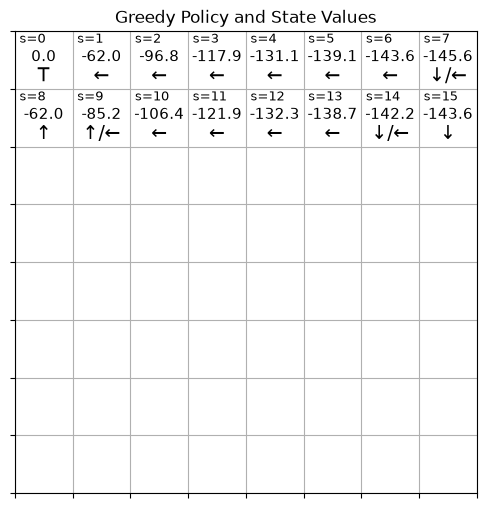

In [10]:
from play_8x8_world_game.view.view_policy import plot_improved_policy
""" See the plot of best actions from each state with their respective state value """
plot_improved_policy(values=vpi_values, best_actions=state_best_actions, grid_size=8)

In [5]:
# improve policy
from play_8x8_world_game.policy_improvement import improve_greedy_policy
greedy_policy = improve_greedy_policy(env2, vpi_values)
greedy_policy

GreedyPolicy : action_map={0: (), 1: (<Action.LEFT: (-1, 0)>,), 2: (<Action.LEFT: (-1, 0)>,), 3: (<Action.LEFT: (-1, 0)>,), 4: (<Action.LEFT: (-1, 0)>,), 5: (<Action.LEFT: (-1, 0)>,), 6: (<Action.LEFT: (-1, 0)>,), 7: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>), 8: (<Action.UP: (0, -1)>,), 9: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>), 10: (<Action.LEFT: (-1, 0)>,), 11: (<Action.LEFT: (-1, 0)>,), 12: (<Action.LEFT: (-1, 0)>,), 13: (<Action.LEFT: (-1, 0)>,), 14: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>), 15: (<Action.DOWN: (0, 1)>,), 16: (<Action.UP: (0, -1)>,), 17: (<Action.UP: (0, -1)>,), 18: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>), 19: (<Action.LEFT: (-1, 0)>,), 20: (<Action.LEFT: (-1, 0)>,), 21: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>), 22: (<Action.DOWN: (0, 1)>,), 23: (<Action.DOWN: (0, 1)>,), 24: (<Action.UP: (0, -1)>,), 25: (<Action.UP: (0, -1)>,), 26: (<Action.UP: (0, -1)>,), 27: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>), 28: (<Action.DOWN: (0, 1

In [6]:
# see the state -> actions probabilities

from play_8x8_world_game.environment import Action

state_action_map = defaultdict(dict)
for state in env2.states:
    for action in env2.actions:
        state_action_map[state][action.name] = greedy_policy.probability(state, action)

state_action_map

defaultdict(dict,
            {0: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             1: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             2: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             3: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             4: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             5: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             6: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             7: {'UP': 0.0, 'DOWN': 0.5, 'LEFT': 0.5, 'RIGHT': 0.0},
             8: {'UP': 1.0, 'DOWN': 0.0, 'LEFT': 0.0, 'RIGHT': 0.0},
             9: {'UP': 0.5, 'DOWN': 0.0, 'LEFT': 0.5, 'RIGHT': 0.0},
             10: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             11: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             12: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
             13: {'UP': 0.0, 'DOWN': 0.0, 'LEFT': 1.0, 'RIGHT': 0.0},
            

In [7]:
# policy iteration
from play_8x8_world_game.policy_iteration import policy_iteration

env3 = GridWorld8x8()
greedy_policy, vpi_values_2, iteration = policy_iteration(env3)

greedy_policy.action_map, vpi_values_2, iteration

({0: (),
  1: (<Action.LEFT: (-1, 0)>,),
  2: (<Action.LEFT: (-1, 0)>,),
  3: (<Action.LEFT: (-1, 0)>,),
  4: (<Action.LEFT: (-1, 0)>,),
  5: (<Action.LEFT: (-1, 0)>,),
  6: (<Action.LEFT: (-1, 0)>,),
  7: (<Action.DOWN: (0, 1)>, <Action.LEFT: (-1, 0)>),
  8: (<Action.UP: (0, -1)>,),
  9: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  10: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  11: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  12: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  13: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  14: (<Action.UP: (0, -1)>,
   <Action.DOWN: (0, 1)>,
   <Action.LEFT: (-1, 0)>,
   <Action.RIGHT: (1, 0)>),
  15: (<Action.DOWN: (0, 1)>,),
  16: (<Action.UP: (0, -1)>,),
  17: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  18: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  19: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  20: (<Action.UP: (0, -1)>, <Action.LEFT: (-1, 0)>),
  21: (<Action.UP: (0, -1)>,
   <Action.DOWN: (0, 1)>,
  

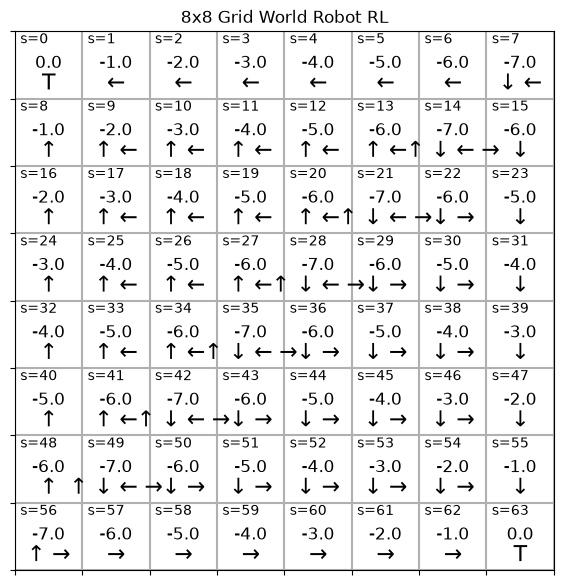

In [8]:
from play_8x8_world_game.view.view_policy import plot_iterated_policy

plot_iterated_policy(greedy_policy.action_map, vpi_values_2, 8, "8x8 Grid World Robot RL")